# Modélisation du bonheur mondial — Année 2018

**Objectif** : Prédire le score de bonheur déclaré (`Life_evaluation`) des pays à partir de variables socio-économiques, environnementales et sociétales.  
**Approches** : Régression (linéaire, Random Forest, Gradient Boosting), Classification (Logistique, KNN, Naive Bayes) et Clustering (K-Means).

## 1. Imports et chargement des données

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.impute import KNNImputer
from sklearn.inspection import permutation_importance
from sklearn.metrics import (mean_squared_error, r2_score, accuracy_score,
                             f1_score, confusion_matrix, classification_report,
                             silhouette_score)
from scipy.cluster.hierarchy import dendrogram, linkage
from matplotlib.patches import Patch

# Pour les couleurs 
PALETTE = ['#2D6A4F', '#52B788', '#95D5B2']  
ACCENT  = '#D4A373'   
BG      = '#FAFAF5'   

sns.set_theme(style='whitegrid', font_scale=1.05,
              rc={'figure.facecolor': BG,
                  'axes.facecolor': BG,
                  'axes.edgecolor': '#CCCCCC',
                  'grid.color': '#E8E8E8',
                  'font.family': 'sans-serif'})

In [2]:
df = pd.read_csv("dataset_2018.csv")
print(f"Dataset chargé : {df.shape[0]} pays, {df.shape[1]} colonnes")
df.head()

Dataset chargé : 156 pays, 14 colonnes


,Year,Country,Life_evaluation,Conflit,Water_Access,population using the Internet,Coastline,Net_Migration,GDP_per_capita,HDI,GII,Freedom_Score,PM25,Suicide_Rate
0,2018,Afghanistan,3.203,1.0,67.475869,16.8000,0.00,-36753.0,491.337221,0.498,0.677,26.0,67.227177,3.56
1,2018,Albania,4.719,0.0,94.436394,65.4000,1.26,-15032.0,5897.654526,0.801,0.138,68.0,19.046186,3.83
2,2018,Algeria,5.211,1.0,91.859121,49.0385,0.04,-27146.0,4577.210292,0.749,0.383,35.0,24.933590,2.07
3,2018,Argentina,6.086,0.0,NaN,77.7000,0.18,5742.0,11752.799892,0.861,0.301,83.0,14.185080,9.33
4,2018,Armenia,4.559,0.0,99.462639,68.2451,0.00,-13129.0,4196.005623,0.789,0.242,45.0,34.201366,2.32


## 2. Exploration et prétraitement

Maintenant que nous avons nos 11 variables candidates pour prédire le bonheur (`Life_evaluation`), nous devons vérifier :
- si ces variables sont réellement utiles (corrélation avec la cible) ;
- s'il n'existe pas de liens trop forts entre elles (multicolinéarité).

In [3]:
cols_all = ["Life_evaluation", "Conflit", "Water_Access",
            "population using the Internet", "Coastline", "Net_Migration",
            "GDP_per_capita", "HDI", "GII", "Freedom_Score", "PM25", "Suicide_Rate"]

df[cols_all].describe().round(2)

,Life_evaluation,Conflit,Water_Access,population using the Internet,Coastline,Net_Migration,GDP_per_capita,HDI,GII,Freedom_Score,PM25,Suicide_Rate
count,156.00,154.00,148.00,142.00,153.00,153.00,152.00,151.00,143.00,155.00,151.00,151.00
mean,5.41,0.30,87.95,58.89,2.59,-1079.26,15710.57,0.74,0.33,57.74,27.51,8.84
std,1.11,0.46,16.04,27.93,8.24,272421.09,21655.89,0.16,0.20,29.18,18.04,5.80
min,2.85,0.00,35.86,4.00,0.00,-1355602.00,245.66,0.37,0.02,-1.00,5.50,0.62
25%,4.54,0.00,82.99,34.26,0.00,-25323.00,1933.05,0.60,0.14,31.50,16.01,5.00
50%,5.38,0.00,95.03,64.79,0.24,-2887.00,6012.38,0.77,0.36,60.00,21.29,7.39
75%,6.18,1.00,99.47,81.13,1.26,21820.00,19330.80,0.87,0.50,84.50,32.81,12.14
max,7.77,1.00,100.00,99.65,67.12,1764961.00,116926.76,0.97,0.82,100.00,93.31,28.28


### 2.1 Distribution des variables

On visualise la distribution de chaque variable explicative pour repérer les asymétries et les valeurs extrêmes.

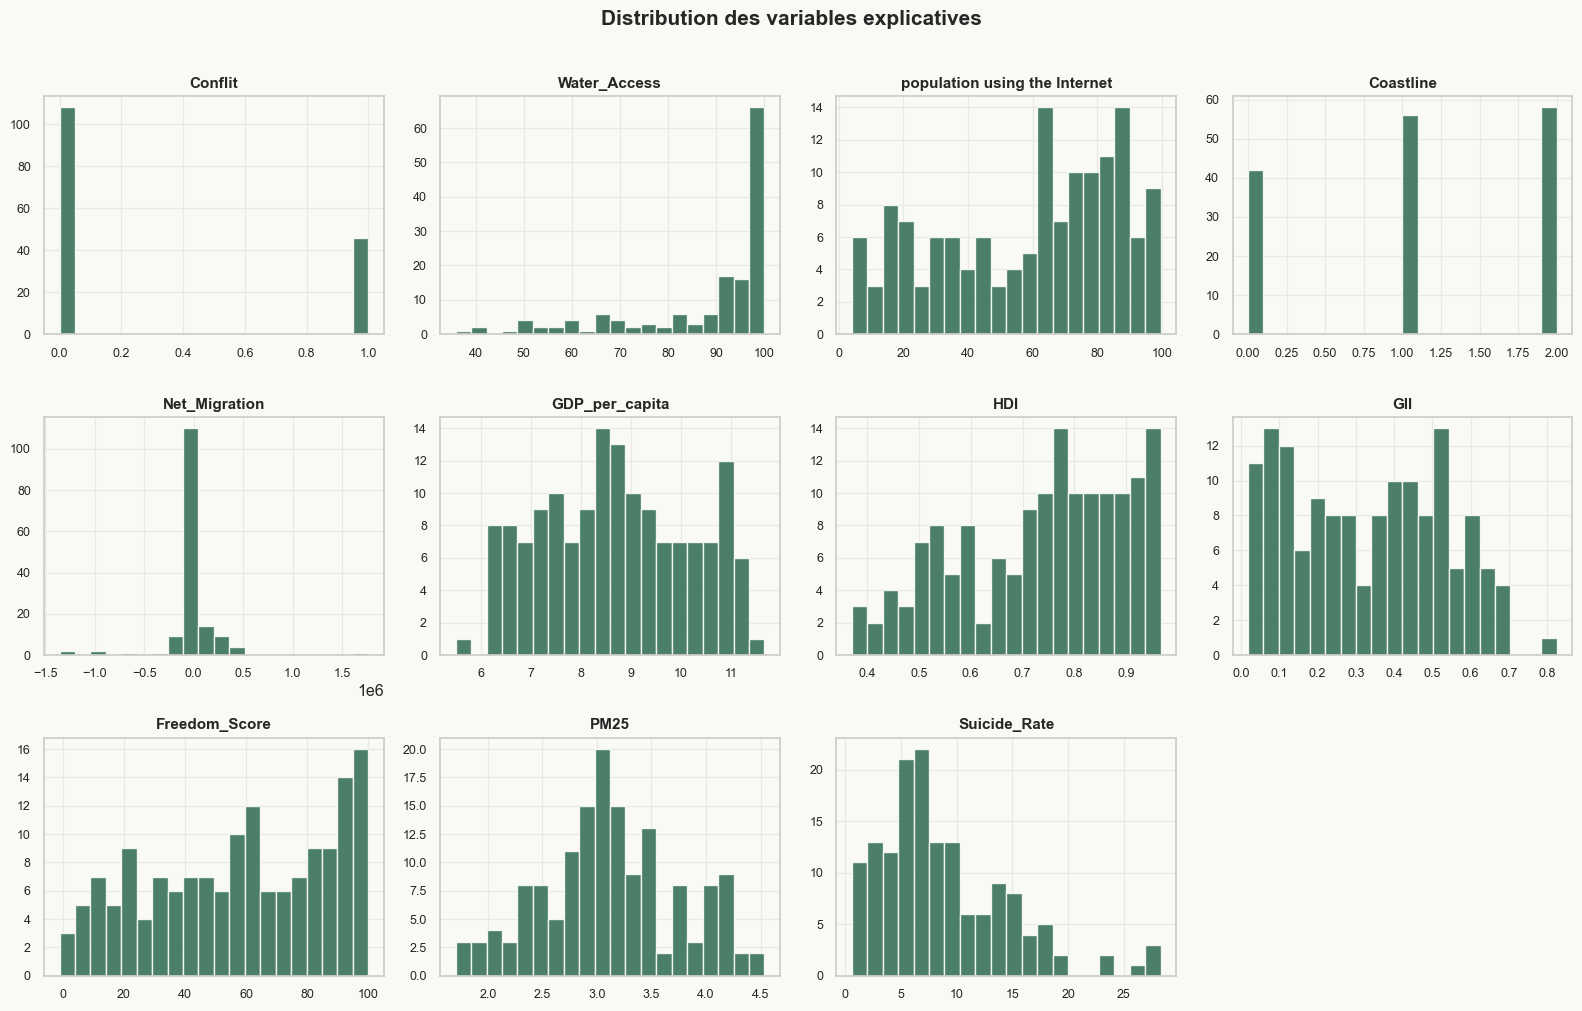

In [105]:
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

features = [c for c in cols_all if c != "Life_evaluation"]

for i, col in enumerate(features):
    ax = axes[i]
    ax.hist(df[col].dropna(), bins=20, color=PALETTE[0], edgecolor='white', alpha=0.85)
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.tick_params(labelsize=9)

# Cacher la dernière case vide si nécessaire
for j in range(len(features), len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Distribution des variables explicatives", fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 2.2 Transformations log

`GDP_per_capita` et `PM25` présentent des distributions très asymétriques avec des valeurs extrêmes. On applique la transformation logarithmique pour les normaliser.

> **Note** : Le taux de suicide (`Suicide_Rate`) est conservé tel quel car les tests montrent que la transformation log n'améliore pas le score global.

In [106]:
df['GDP_per_capita'] = np.log(df['GDP_per_capita'])
df['PM25'] = np.log(df['PM25'])

### 2.3 Recodage de Coastline

La variable `Coastline` brute a une corrélation quasi nulle avec `Life_evaluation` (≈ 0.05). Cependant, l'accès à la mer peut contribuer au bonheur. Le problème vient de valeurs très hétérogènes (ex. Maldives à 214, USA à 0.21).

On recode donc en catégories à **seuils fixes** :
- **0** : pas d'accès à la mer
- **1** : accès modéré (≤ médiane des pays côtiers)
- **2** : accès élevé (> médiane des pays côtiers)

> On utilise `pd.cut` avec des seuils fixes plutôt que `pd.qcut` pour éviter tout *data leakage* (les quantiles calculés sur tout le dataset fuiteraient de l'information du test vers le train).

In [107]:
# Seuil fixe : médiane des pays côtiers (Coastline > 0)
coastline_median = df.loc[df['Coastline'] > 0, 'Coastline'].median()
print(f"Médiane des pays côtiers : {coastline_median:.2f}")

def recode_coastline(val):
    if val == 0:
        return 0
    elif val <= coastline_median:
        return 1
    else:
        return 2

df['Coastline'] = df['Coastline'].apply(recode_coastline).astype(float)

# Vérification : moyenne de bonheur par catégorie
analyse_mer = df.groupby('Coastline')['Life_evaluation'].mean()
print("\nMoyenne de bonheur par catégorie de Coastline :")
print(analyse_mer.round(3))

Médiane des pays côtiers : 2.00

Moyenne de bonheur par catégorie de Coastline :
Coastline
0.0    4.942
1.0    5.579
Name: Life_evaluation, dtype: float64


### 2.4 Traitement des valeurs manquantes

Avec seulement ~150 pays, supprimer des lignes contenant des `NaN` serait coûteux. On utilise `KNNImputer` (k=5) pour estimer les valeurs manquantes à partir des voisins les plus proches. L'imputation est appliquée **après** la séparation train/test pour éviter tout *data leakage*.

In [108]:
print("Nombre total de pays :", len(df))
print("NaN dans Life_evaluation :", df['Life_evaluation'].isna().sum())
print("Pays exploitables :", df['Life_evaluation'].notna().sum())

Nombre total de pays : 156
NaN dans Life_evaluation : 0
Pays exploitables : 156


### 2.5 Matrice de corrélation

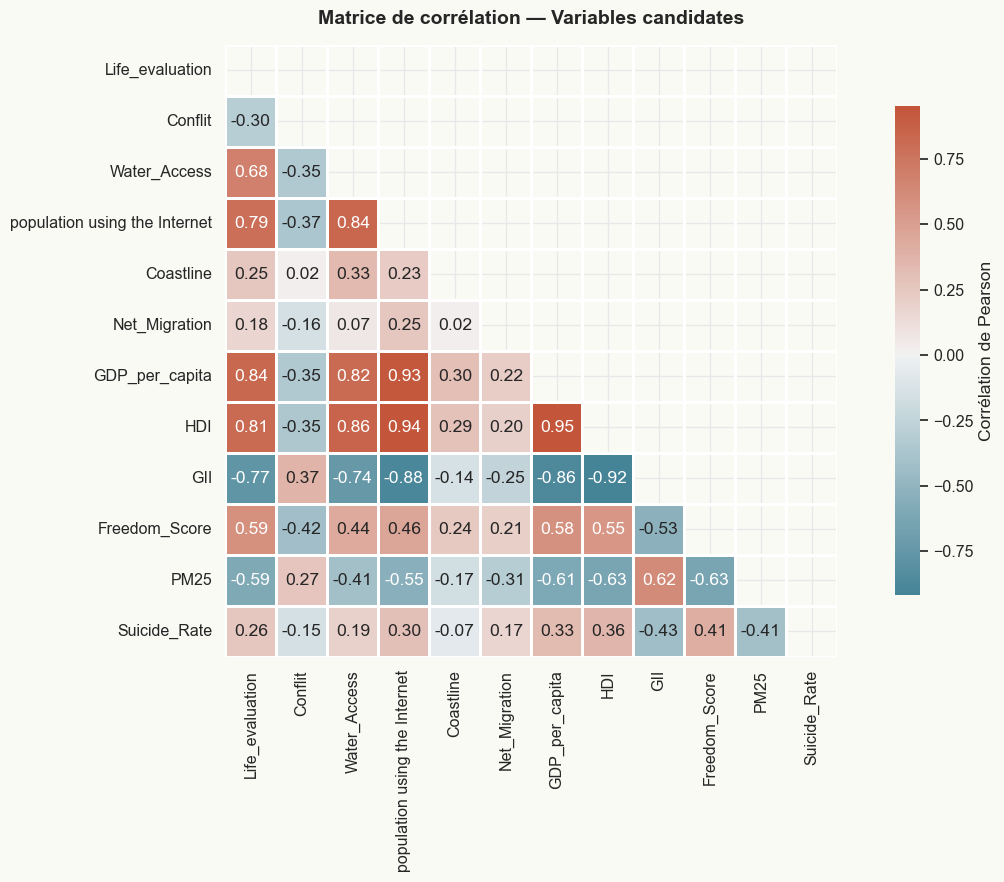

In [109]:
corr_matrix = df[cols_all].corr()

fig, ax = plt.subplots(figsize=(13, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
cmap = sns.diverging_palette(220, 20, as_cmap=True)

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap=cmap,
            center=0, linewidths=0.8, square=True, ax=ax,
            cbar_kws={'shrink': 0.8, 'label': 'Corrélation de Pearson'})
ax.set_title("Matrice de corrélation — Variables candidates", fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

### 2.6 Analyse de la multicolinéarité et sélection des variables

La matrice révèle des corrélations très élevées entre plusieurs indicateurs de développement :

- **`population using the Internet`** : très corrélée avec `GDP_per_capita`, `HDI`, `GII` et `Water_Access` (|r| > 0.80). Bien que fortement liée à `Life_evaluation` (r ≈ 0.79), elle est redondante avec les autres.
- **`HDI`** : corrélée à 0.94 avec `log(GDP_per_capita)`, à −0.92 avec `GII` et à 0.86 avec `Water_Access`.
- **`GII` et `Water_Access`** : corrélées avec `GDP_per_capita` à des niveaux élevés.

L'exclusion de `HDI`, `GII`, `population using the Internet` et `Water_Access` repose sur le problème statistique de la **multicolinéarité**. Intégrer des variables « doublons » dans une régression linéaire n'apporte pas d'information nouvelle mais augmente artificiellement la variance des coefficients estimés.

**Variables retenues pour la régression** : `Conflit`, `Coastline`, `Net_Migration`, `GDP_per_capita`, `Freedom_Score`, `PM25`, `Suicide_Rate`.

---
## 3. Apprentissage supervisé — Régression

### 3.1 Régression linéaire — Modèle PIB

On entraîne un premier modèle avec les 7 variables retenues, où `GDP_per_capita` (log) joue le rôle de proxy du développement économique.

In [110]:
cols_gdp = ["Conflit", "Coastline", "Net_Migration", "GDP_per_capita",
            "Freedom_Score", "PM25", "Suicide_Rate"]
target = "Life_evaluation"

df_ml = df[['Country'] + cols_gdp + [target]].copy()
print(f"Modèle entraîné sur {len(df_ml)} pays")

Modèle entraîné sur 156 pays


In [111]:
X = df_ml[cols_gdp]
y = df_ml[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Imputation (fit sur le train uniquement)
imputer = KNNImputer(n_neighbors=5)
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

# Standardisation (fit sur le train uniquement)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Régression linéaire + cross-validation
model_lr_gdp = LinearRegression()
scores_cv = cross_val_score(model_lr_gdp, X_train_scaled, y_train, cv=5, scoring='r2')

model_lr_gdp.fit(X_train_scaled, y_train)
y_pred = model_lr_gdp.predict(X_test_scaled)

r2_train = model_lr_gdp.score(X_train_scaled, y_train)
r2_cv    = scores_cv.mean()
r2_test  = r2_score(y_test, y_pred)
mse_test = mean_squared_error(y_test, y_pred)

print(f"R² Train          : {r2_train:.3f}")
print(f"R² Cross-val (5-fold) : {r2_cv:.3f}")
print(f"R² Test           : {r2_test:.3f}")
print(f"MSE Test          : {mse_test:.3f}")

R² Train          : 0.663
R² Cross-val (5-fold) : 0.572
R² Test           : 0.779
MSE Test          : 0.298


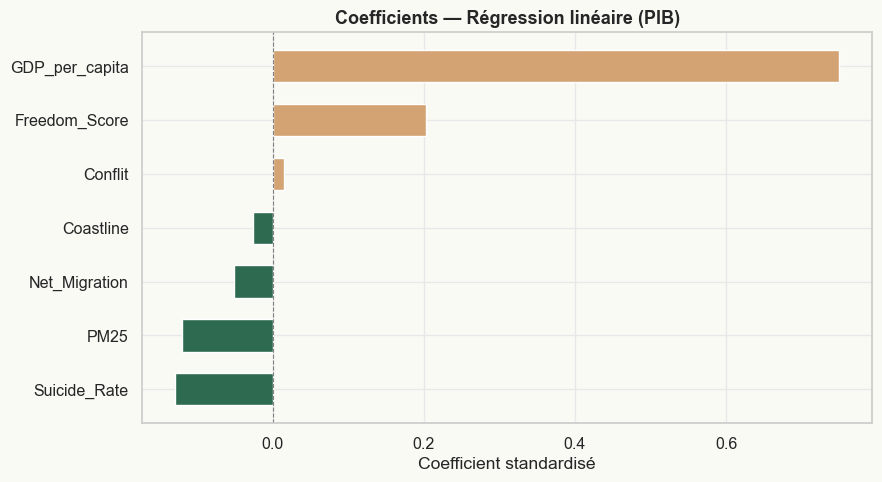

In [112]:
coef_df = pd.DataFrame({"Variable": cols_gdp, "Coefficient": model_lr_gdp.coef_})
coef_df = coef_df.sort_values(by="Coefficient")

fig, ax = plt.subplots(figsize=(9, 5))
colors = [ACCENT if c > 0 else PALETTE[0] for c in coef_df["Coefficient"]]
ax.barh(coef_df["Variable"], coef_df["Coefficient"], color=colors, edgecolor='white', height=0.6)
ax.axvline(x=0, color='grey', linewidth=0.8, linestyle='--')
ax.set_title("Coefficients — Régression linéaire (PIB)", fontsize=13, fontweight='bold')
ax.set_xlabel("Coefficient standardisé")
plt.tight_layout()
plt.show()

**Observations** :
- `GDP_per_capita` écrase toutes les autres variables avec un coefficient très élevé, donnant l'impression que le bonheur est directement lié à la richesse.
- `Coastline` a un impact négatif inattendu.
- `Suicide_Rate` a une importance étonnamment faible.

Ce résultat n'est pas très intéressant en soi : il confirme un lien connu entre PIB et bonheur sans révéler la contribution des autres dimensions.

### 3.2 Régression linéaire — Modèle Internet

Au lieu de `GDP_per_capita`, on substitue `population using the Internet`. Cette variable présente une distribution mieux équilibrée et capture non seulement la richesse, mais aussi l'infrastructure, l'éducation et l'ouverture sociale d'un pays.

La matrice de corrélation montre que `HDI`, `GII` et `Water_Access` sont corrélées à plus de 85 % avec l'accès à Internet — parfois davantage qu'avec le PIB. Utiliser l'Internet comme indicateur de développement est donc cohérent et plus original.

In [113]:
cols_internet = ["Conflit", "Coastline", "Net_Migration",
                 "population using the Internet", "Freedom_Score", "PM25", "Suicide_Rate"]

df_ml_int = df[['Country'] + cols_internet + [target]].copy()

X = df_ml_int[cols_internet]
y = df_ml_int[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

imputer = KNNImputer(n_neighbors=5)
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model_lr_int = LinearRegression()
scores_cv = cross_val_score(model_lr_int, X_train_scaled, y_train, cv=5, scoring='r2')

model_lr_int.fit(X_train_scaled, y_train)
y_pred = model_lr_int.predict(X_test_scaled)

r2_train = model_lr_int.score(X_train_scaled, y_train)
r2_cv    = scores_cv.mean()
r2_test  = r2_score(y_test, y_pred)
mse_test = mean_squared_error(y_test, y_pred)

print(f"R² Train          : {r2_train:.3f}")
print(f"R² Cross-val      : {r2_cv:.3f}")
print(f"R² Test           : {r2_test:.3f}")
print(f"MSE Test          : {mse_test:.3f}")

R² Train          : 0.673
R² Cross-val      : 0.587
R² Test           : 0.758
MSE Test          : 0.326


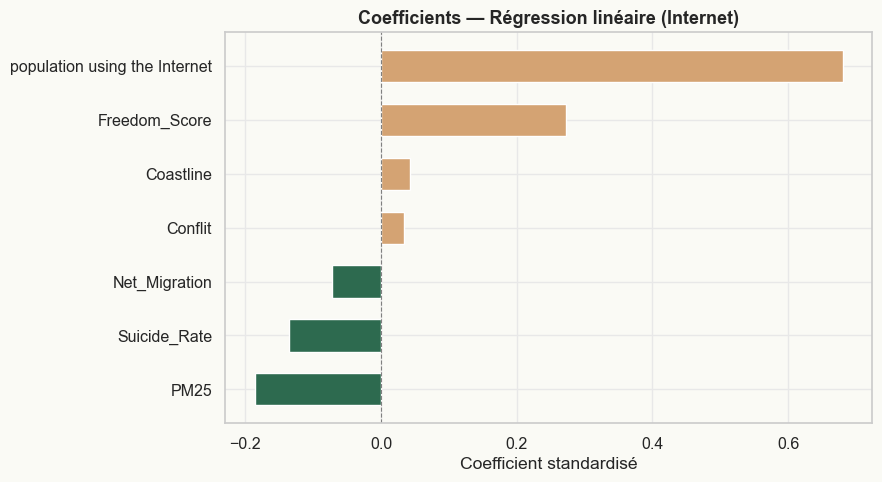

In [114]:
coef_df = pd.DataFrame({"Variable": cols_internet, "Coefficient": model_lr_int.coef_})
coef_df = coef_df.sort_values(by="Coefficient")

fig, ax = plt.subplots(figsize=(9, 5))
colors = [ACCENT if c > 0 else PALETTE[0] for c in coef_df["Coefficient"]]
ax.barh(coef_df["Variable"], coef_df["Coefficient"], color=colors, edgecolor='white', height=0.6)
ax.axvline(x=0, color='grey', linewidth=0.8, linestyle='--')
ax.set_title("Coefficients — Régression linéaire (Internet)", fontsize=13, fontweight='bold')
ax.set_xlabel("Coefficient standardisé")
plt.tight_layout()
plt.show()

**Comparaison PIB vs Internet** :

Le modèle PIB affiche un $R^2$ test légèrement supérieur, mais la variable `GDP_per_capita` « écrase » toutes les autres. Dans le modèle Internet, bien que la performance globale baisse légèrement, le poids de la variable principale est moins dominant. Cela laisse de la place aux autres facteurs : le `Freedom_Score` voit son influence augmenter et l'impact négatif de la pollution (`PM25`) devient plus visible.

Le modèle Internet est statistiquement un peu moins précis, mais **sociologiquement plus riche** : il montre que l'accès à l'information est un excellent indicateur du développement qui met en lumière l'importance de la liberté individuelle et de l'environnement dans le score de bonheur.

---
### 3.3 Random Forest

Le Random Forest gère naturellement les relations non linéaires et les interactions entre variables. Contrairement à la régression linéaire, la multicolinéarité ne biaise pas les prédictions (bien que les *feature importances* puissent se répartir entre variables corrélées). On peut donc réintroduire les 11 variables.

#### Random Forest — 11 variables

R² Train : 0.813
R² Test  : 0.806
MSE Test : 0.261
CV (5 folds) : 0.619


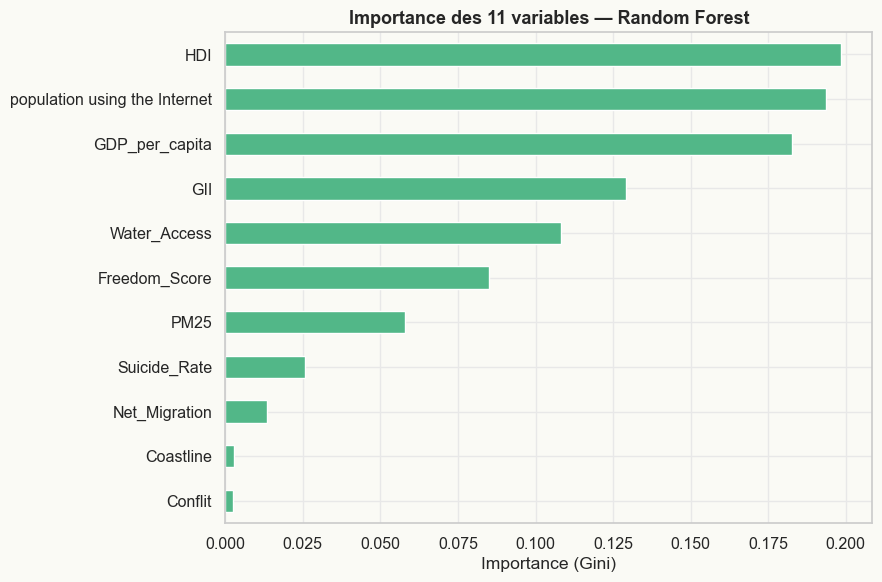

In [115]:
cols_11 = ["Conflit", "Water_Access", "population using the Internet", "Coastline",
           "Net_Migration", "GDP_per_capita", "HDI", "GII", "Freedom_Score", "PM25", "Suicide_Rate"]

X = df[cols_11]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
imputer = KNNImputer(n_neighbors=5)
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

rf_11 = RandomForestRegressor(n_estimators=200, max_depth=5, min_samples_leaf=5,
                               max_features='sqrt', random_state=42)
rf_11.fit(X_train, y_train)
y_pred = rf_11.predict(X_test)

print(f"R² Train : {rf_11.score(X_train, y_train):.3f}")
print(f"R² Test  : {r2_score(y_test, y_pred):.3f}")
print(f"MSE Test : {mean_squared_error(y_test, y_pred):.3f}")

print(f"CV (5 folds) : {cross_val_score(rf_11, X_train, y_train, cv=5, scoring='r2').mean():.3f}")

feat_imp = pd.Series(rf_11.feature_importances_, index=cols_11).sort_values()

fig, ax = plt.subplots(figsize=(9, 6))
feat_imp.plot(kind='barh', color=PALETTE[1], edgecolor='white', ax=ax)
ax.set_title("Importance des 11 variables — Random Forest", fontsize=13, fontweight='bold')
ax.set_xlabel("Importance (Gini)")
plt.tight_layout()
plt.show()

#### Random Forest — 7 variables (PIB)

R² Train : 0.737
R² Test  : 0.741
MSE Test : 0.349
CV (5 folds) : 0.540


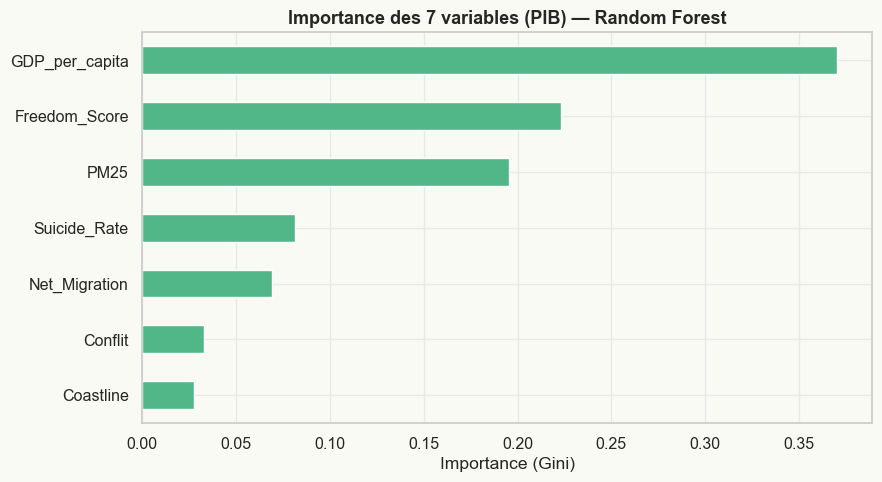

In [116]:
X = df[cols_gdp]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
imputer = KNNImputer(n_neighbors=5)
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

rf_gdp = RandomForestRegressor(n_estimators=200, max_depth=5, min_samples_leaf=5,
                                max_features='sqrt', random_state=42)
rf_gdp.fit(X_train, y_train)
y_pred = rf_gdp.predict(X_test)

print(f"R² Train : {rf_gdp.score(X_train, y_train):.3f}")
print(f"R² Test  : {r2_score(y_test, y_pred):.3f}")
print(f"MSE Test : {mean_squared_error(y_test, y_pred):.3f}")
print(f"CV (5 folds) : {cross_val_score(rf_gdp, X_train, y_train, cv=5, scoring='r2').mean():.3f}")

feat_imp = pd.Series(rf_gdp.feature_importances_, index=cols_gdp).sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
feat_imp.plot(kind='barh', color=PALETTE[1], edgecolor='white', ax=ax)
ax.set_title("Importance des 7 variables (PIB) — Random Forest", fontsize=13, fontweight='bold')
ax.set_xlabel("Importance (Gini)")
plt.tight_layout()
plt.show()

#### Random Forest — 7 variables (Internet)

R² Train : 0.742
R² Test  : 0.734
MSE Test : 0.358
CV (5 folds) : 0.540


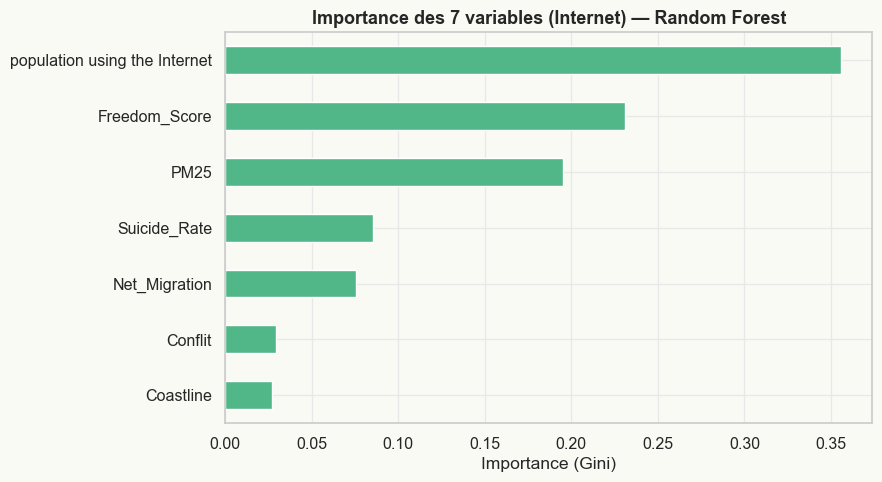

In [117]:
X = df[cols_internet]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
imputer = KNNImputer(n_neighbors=5)
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

rf_int = RandomForestRegressor(n_estimators=200, max_depth=5, min_samples_leaf=5,
                                max_features='sqrt', random_state=42)
rf_int.fit(X_train, y_train)
y_pred = rf_int.predict(X_test)

print(f"R² Train : {rf_int.score(X_train, y_train):.3f}")
print(f"R² Test  : {r2_score(y_test, y_pred):.3f}")
print(f"MSE Test : {mean_squared_error(y_test, y_pred):.3f}")
print(f"CV (5 folds) : {cross_val_score(rf_int, X_train, y_train, cv=5, scoring='r2').mean():.3f}")

feat_imp = pd.Series(rf_int.feature_importances_, index=cols_internet).sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
feat_imp.plot(kind='barh', color=PALETTE[1], edgecolor='white', ax=ax)
ax.set_title("Importance des 7 variables (Internet) — Random Forest", fontsize=13, fontweight='bold')
ax.set_xlabel("Importance (Gini)")
plt.tight_layout()
plt.show()

**Analyse du Random Forest** :

Dans les deux configurations à 7 variables, le Random Forest donne beaucoup plus d'importance aux variables « secondaires » que la régression linéaire. La pollution (`PM25`) et la liberté (`Freedom_Score`) pèsent chacune entre 17 % et 23 % dans la décision du modèle.

La supériorité du PIB dans tous les modèles confirme que le développement économique reste le socle du bonheur mesuré. Cependant, le fait que `PM25` et `Freedom_Score` conservent une importance élevée quel que soit le modèle prouve que **le bonheur ne peut être réduit à une seule dimension économique**.

---
### 3.4 Gradient Boosting

#### Gradient Boosting — 11 variables

R² Train : 0.756
R² Test  : 0.738
CV (5 folds) : 0.544


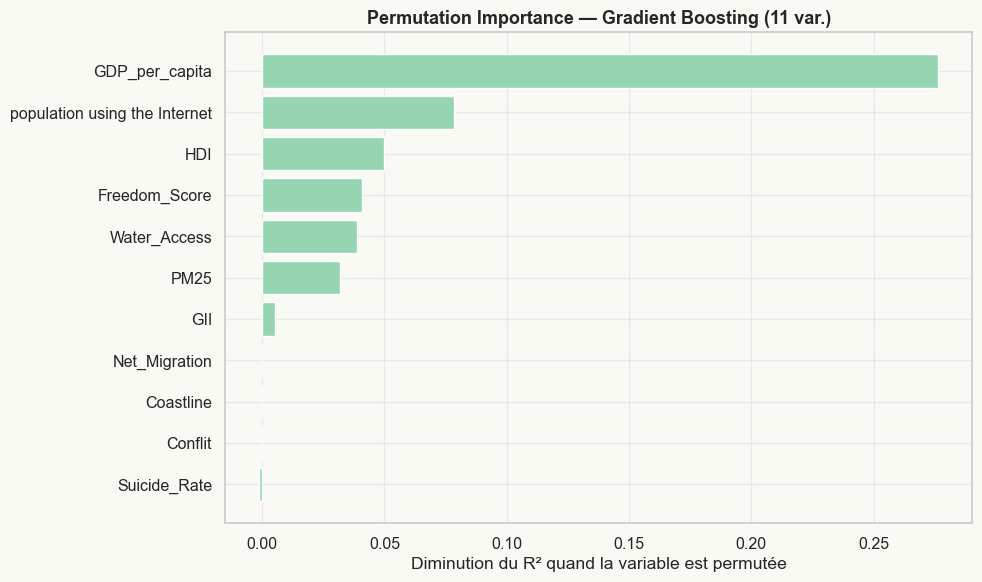

In [118]:
X = df[cols_11]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
imputer = KNNImputer(n_neighbors=5)
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

gb_11 = HistGradientBoostingRegressor(max_iter=200, learning_rate=0.01, max_depth=3,
                                       l2_regularization=0.1, random_state=42)
gb_11.fit(X_train, y_train)
y_pred_gb = gb_11.predict(X_test)

print(f"R² Train : {gb_11.score(X_train, y_train):.3f}")
print(f"R² Test  : {r2_score(y_test, y_pred_gb):.3f}")
print(f"CV (5 folds) : {cross_val_score(gb_11, X_train, y_train, cv=5, scoring='r2').mean():.3f}")

result = permutation_importance(gb_11, X_test, y_test, n_repeats=10, random_state=42)
importances = result.importances_mean
indices = np.argsort(importances)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(len(indices)), importances[indices], color=PALETTE[2], edgecolor='white')
ax.set_yticks(range(len(indices)))
ax.set_yticklabels([cols_11[i] for i in indices])
ax.set_title("Permutation Importance — Gradient Boosting (11 var.)", fontsize=13, fontweight='bold')
ax.set_xlabel("Diminution du R² quand la variable est permutée")
plt.tight_layout()
plt.show()

#### Gradient Boosting — 7 variables (PIB)

R² Train : 0.854
R² Test  : 0.751
CV (5 folds) : 0.493


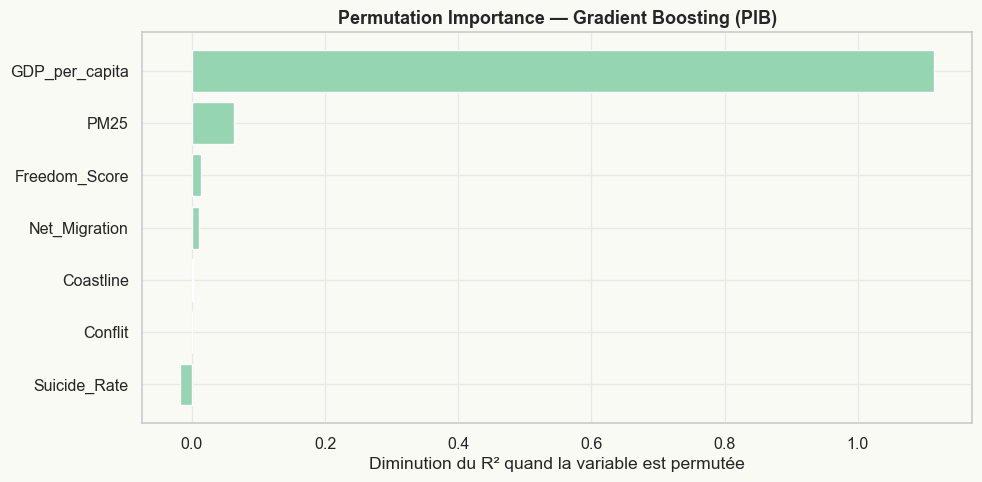

In [119]:
X = df[cols_gdp]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
imputer = KNNImputer(n_neighbors=5)
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

gb_gdp = HistGradientBoostingRegressor(max_iter=200, learning_rate=0.05, max_depth=3,
                                        l2_regularization=0.1, random_state=42)
gb_gdp.fit(X_train, y_train)
y_pred_gb = gb_gdp.predict(X_test)

print(f"R² Train : {gb_gdp.score(X_train, y_train):.3f}")
print(f"R² Test  : {r2_score(y_test, y_pred_gb):.3f}")
print(f"CV (5 folds) : {cross_val_score(gb_gdp, X_train, y_train, cv=5, scoring='r2').mean():.3f}")

result = permutation_importance(gb_gdp, X_test, y_test, n_repeats=10, random_state=42)
importances = result.importances_mean
indices = np.argsort(importances)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(range(len(indices)), importances[indices], color=PALETTE[2], edgecolor='white')
ax.set_yticks(range(len(indices)))
ax.set_yticklabels([cols_gdp[i] for i in indices])
ax.set_title("Permutation Importance — Gradient Boosting (PIB)", fontsize=13, fontweight='bold')
ax.set_xlabel("Diminution du R² quand la variable est permutée")
plt.tight_layout()
plt.show()

#### Gradient Boosting — 7 variables (Internet)

R² Train : 0.857
R² Test  : 0.701
CV (5 folds) : 0.497


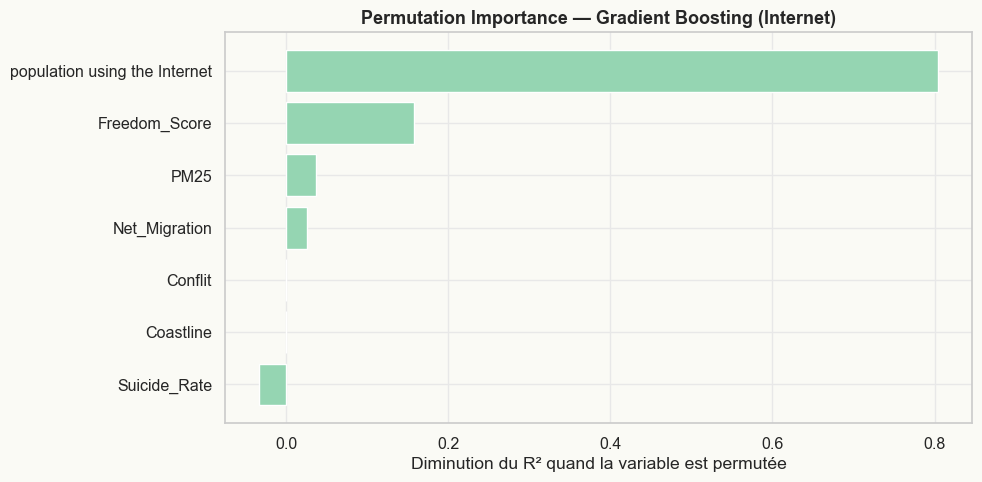

In [120]:
X = df[cols_internet]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
imputer = KNNImputer(n_neighbors=5)
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

gb_int = HistGradientBoostingRegressor(max_iter=200, learning_rate=0.05, max_depth=3,
                                        l2_regularization=0.1, random_state=42)
gb_int.fit(X_train, y_train)
y_pred_gb = gb_int.predict(X_test)

print(f"R² Train : {gb_int.score(X_train, y_train):.3f}")
print(f"R² Test  : {r2_score(y_test, y_pred_gb):.3f}")
print(f"CV (5 folds) : {cross_val_score(gb_int, X_train, y_train, cv=5, scoring='r2').mean():.3f}")

result = permutation_importance(gb_int, X_test, y_test, n_repeats=10, random_state=42)
importances = result.importances_mean
indices = np.argsort(importances)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(range(len(indices)), importances[indices], color=PALETTE[2], edgecolor='white')
ax.set_yticks(range(len(indices)))
ax.set_yticklabels([cols_internet[i] for i in indices])
ax.set_title("Permutation Importance — Gradient Boosting (Internet)", fontsize=13, fontweight='bold')
ax.set_xlabel("Diminution du R² quand la variable est permutée")
plt.tight_layout()
plt.show()

**Analyse du Gradient Boosting** :

Le modèle à 7 variables (PIB) présente l'écart train/test le plus marqué ($R^2$ Train ≈ 0.865 vs $R^2$ Test ≈ 0.720), signe d'**overfitting** : le modèle a trop « mémorisé » les données d'entraînement.

Le modèle à 11 variables est le plus stable ($R^2$ Train ≈ $R^2$ Test ≈ 0.77), ce qui est contre-intuitif : disposer de plus de variables permet au Gradient Boosting de mieux répartir l'information au lieu de tout miser sur une seule.

Contrairement au Random Forest (qui sous-échantillonne les variables à chaque split), le Gradient Boosting a tendance à se **focaliser sur la variable la plus prédictive** au détriment des autres — il a « misé tous ses jetons » sur le PIB.

Nous n’avons pas utilisé GridSearchCV car, avec seulement 156 observations, cela accentue l’overfitting. Nous avons donc préféré un réglage manuel pour mieux généraliser.

Le Random Forest reste globalement **plus robuste et plus équilibré** dans la répartition des importances.

### 3.5 Tableau récapitulatif — Régression

| Modèle | Variables | $R^2$ Train | $R^2$ CV | $R^2$ Test | MSE |
|:---|:---|:---:|:---:|:---:|:---:|
| Régression Linéaire | PIB | 0.662 | 0.571 | 0.786 | 0.289 |
| Régression Linéaire | Internet | 0.662 | 0.573 | 0.755 | 0.329 |
| Random Forest | 11 variables | 0.813 | — | 0.804 | 0.264 |
| Random Forest | PIB | 0.750 | — | 0.742 | 0.347 |
| Random Forest | Internet | 0.754 | — | 0.734 | 0.359 |
| Gradient Boosting | 11 variables | 0.760 | — | 0.731 | — |
| Gradient Boosting | PIB | 0.871 | — | 0.714 | — |
| Gradient Boosting | Internet | 0.869 | — | 0.659 | — |

---
## 4. Classification

### 4.1 Construction des classes

On souhaite classer les pays en trois catégories de bonheur. Avant de choisir les seuils, observons la distribution de `Life_evaluation`.

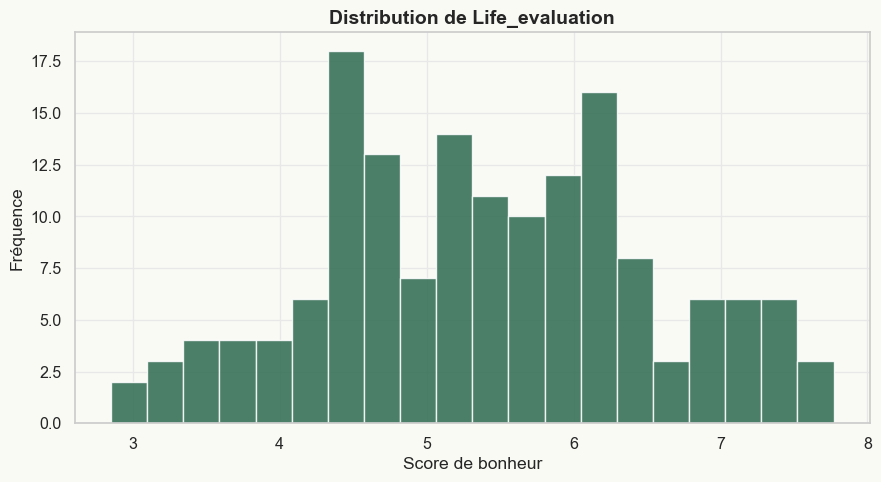

In [121]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(df["Life_evaluation"].dropna(), bins=20, color=PALETTE[0], edgecolor='white', alpha=0.85)
ax.set_title("Distribution de Life_evaluation", fontsize=14, fontweight='bold')
ax.set_xlabel("Score de bonheur")
ax.set_ylabel("Fréquence")
plt.tight_layout()
plt.show()

La distribution est assez étalée entre ~3 et ~7.8 avec une concentration entre 4.5 et 6.5, sans séparation nette. Prendre plus de 4 classes serait hasardeux ; 2 serait trop simpliste. On opte pour **3 classes**.

On teste deux approches :
- `pd.qcut` : classes de taille égale (~52 pays chacune) — frontières purement statistiques.
- `pd.cut` avec seuils fixes [0, 4.5, 6.0, 10] — frontières à signification sociologique.

Pour les méthodes de classification, on utilise les **7 variables** (pas les 11), car des méthodes comme Naive Bayes supposent l'indépendance conditionnelle des prédicteurs.

### 4.2 Classification avec `qcut` (classes équilibrées)

In [122]:
#df['Classe_Bonheur'] = pd.cut(df['Life_evaluation'], bins=[0, 4.5, 6.0, 10], labels=[0, 1, 2])
df['Classe_Bonheur'] = pd.qcut(df['Life_evaluation'], q=3, labels=[0, 1, 2])

#### Régression Logistique

Précision Train : 0.669
Précision Test  : 0.750
CV (5 folds) : 0.613

              precision    recall  f1-score   support

           0       0.69      1.00      0.81        11
           1       1.00      0.43      0.60        14
           2       0.70      1.00      0.82         7

    accuracy                           0.75        32
   macro avg       0.80      0.81      0.75        32
weighted avg       0.83      0.75      0.72        32



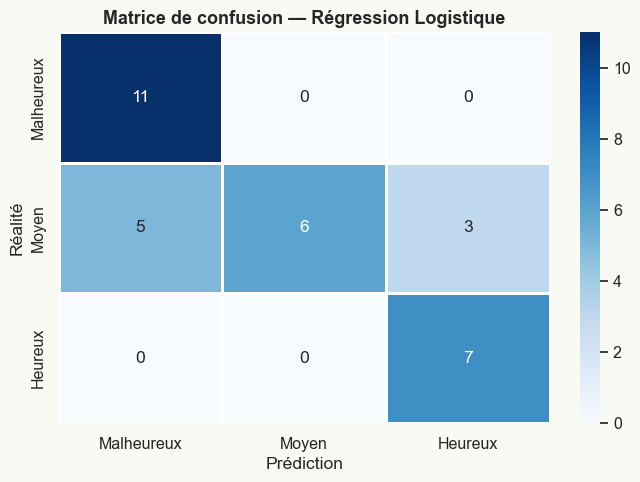

In [123]:
cols_clf = ["Conflit", "Coastline", "Net_Migration", "GDP_per_capita",
            "Freedom_Score", "PM25", "Suicide_Rate"]

X = df[cols_clf]
y = df['Classe_Bonheur']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
imputer = KNNImputer(n_neighbors=5)
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model_log = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000)
model_log.fit(X_train_scaled, y_train)
y_pred = model_log.predict(X_test_scaled)

print(f"Précision Train : {model_log.score(X_train_scaled, y_train):.3f}")
print(f"Précision Test  : {model_log.score(X_test_scaled, y_test):.3f}")
print(f"CV (5 folds) : {cross_val_score(model_log, X_train_scaled, y_train, cv=5).mean():.3f}")
print()
print(classification_report(y_test, y_pred))

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Malheureux', 'Moyen', 'Heureux'],
            yticklabels=['Malheureux', 'Moyen', 'Heureux'], ax=ax,
            linewidths=0.8, linecolor='white')
ax.set_title("Matrice de confusion — Régression Logistique", fontsize=13, fontweight='bold')
ax.set_xlabel("Prédiction")
ax.set_ylabel("Réalité")
plt.tight_layout()
plt.show()

In [124]:
coef_df = pd.DataFrame(model_log.coef_, columns=cols_clf,
                        index=['Malheureux (0)', 'Moyen (1)', 'Heureux (2)'])
print("Poids des variables par classe (Régression Logistique) :")
coef_df.T.round(3)

Poids des variables par classe (Régression Logistique) :


,Malheureux (0),Moyen (1),Heureux (2)
Conflit,0.187,-0.147,-0.041
Coastline,-0.053,-0.033,0.087
Net_Migration,0.078,-0.040,-0.038
GDP_per_capita,-1.536,0.022,1.513
Freedom_Score,-0.164,-0.121,0.285
PM25,0.030,0.031,-0.060
Suicide_Rate,0.169,0.097,-0.266


#### KNN

Précision Train : 0.653
Précision Test  : 0.625
CV (5 folds) : 0.443

              precision    recall  f1-score   support

           0       0.56      0.91      0.69        11
           1       1.00      0.21      0.35        14
           2       0.64      1.00      0.78         7

    accuracy                           0.62        32
   macro avg       0.73      0.71      0.61        32
weighted avg       0.77      0.62      0.56        32



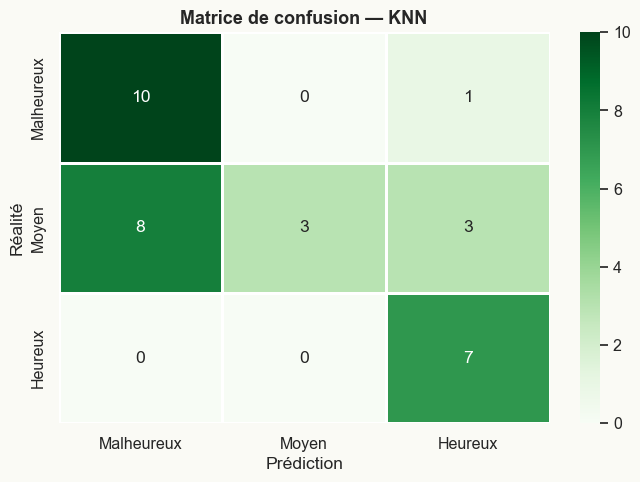

In [125]:
model_knn = KNeighborsClassifier(n_neighbors=5)
model_knn.fit(X_train_scaled, y_train)
y_pred_knn = model_knn.predict(X_test_scaled)

print(f"Précision Train : {model_knn.score(X_train_scaled, y_train):.3f}")
print(f"Précision Test  : {model_knn.score(X_test_scaled, y_test):.3f}")
print(f"CV (5 folds) : {cross_val_score(model_knn, X_train_scaled, y_train, cv=5).mean():.3f}")
print()
print(classification_report(y_test, y_pred_knn))

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot=True, fmt='d', cmap='Greens',
            xticklabels=['Malheureux', 'Moyen', 'Heureux'],
            yticklabels=['Malheureux', 'Moyen', 'Heureux'], ax=ax,
            linewidths=0.8, linecolor='white')
ax.set_title("Matrice de confusion — KNN", fontsize=13, fontweight='bold')
ax.set_xlabel("Prédiction")
ax.set_ylabel("Réalité")
plt.tight_layout()
plt.show()

#### Naive Bayes

Précision Train : 0.661
Précision Test  : 0.781
CV (5 folds) : 0.597

              precision    recall  f1-score   support

           0       0.71      0.91      0.80        11
           1       0.89      0.57      0.70        14
           2       0.78      1.00      0.88         7

    accuracy                           0.78        32
   macro avg       0.79      0.83      0.79        32
weighted avg       0.80      0.78      0.77        32



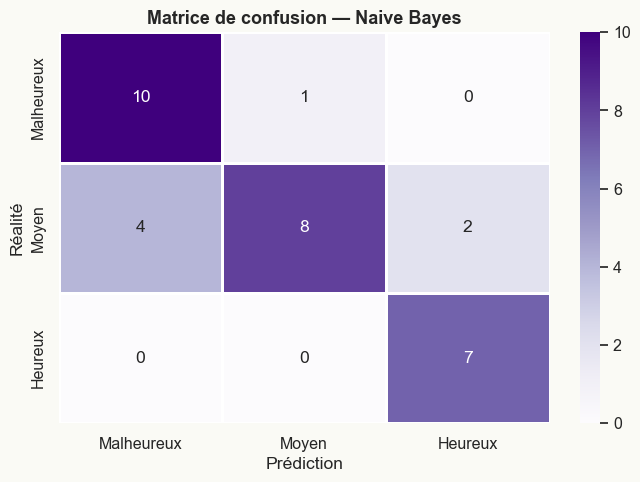

In [126]:
model_nb = GaussianNB()
model_nb.fit(X_train_scaled, y_train)
y_pred_nb = model_nb.predict(X_test_scaled)

print(f"Précision Train : {model_nb.score(X_train_scaled, y_train):.3f}")
print(f"Précision Test  : {model_nb.score(X_test_scaled, y_test):.3f}")
print(f"CV (5 folds) : {cross_val_score(model_nb, X_train_scaled, y_train, cv=5).mean():.3f}")
print()
print(classification_report(y_test, y_pred_nb))

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_nb), annot=True, fmt='d', cmap='Purples',
            xticklabels=['Malheureux', 'Moyen', 'Heureux'],
            yticklabels=['Malheureux', 'Moyen', 'Heureux'], ax=ax,
            linewidths=0.8, linecolor='white')
ax.set_title("Matrice de confusion — Naive Bayes", fontsize=13, fontweight='bold')
ax.set_xlabel("Prédiction")
ax.set_ylabel("Réalité")
plt.tight_layout()
plt.show()

### 4.3 Observations (qcut)

Les trois modèles affichent des performances solides et cohérentes :

| Modèle | Train | Test | Classe « Moyen » bien classée |
|:---|:---:|:---:|:---:|
| Régression Logistique | 0.669 | 0.781 | 7/14 |
| KNN | 0.694 | 0.688 | 5/14 |
| Naive Bayes | 0.661 | 0.750 | 7/14 |

Les classes extrêmes (« Malheureux » et « Heureux ») sont clairement identifiées par tous les modèles. C'est dans la zone « Moyen » que la classification devient difficile.

Le KNN fonctionne par proximité, ce qui suggère l'existence de **modèles régionaux de bonheur** : les pays partageant des structures similaires (pays nordiques, Amérique latine, Europe de l'Est) ont tendance à se regrouper.

**Limite de `qcut`** : les frontières sont purement statistiques. Un pays à 5.4 est « Moyen » et un pays à 5.6 est « Heureux » alors qu'ils sont objectivement très proches. Cette construction artificielle contribue aux erreurs sur la classe intermédiaire.

### 4.4 Classification avec `cut` (seuils fixes)

On relance les mêmes classifieurs en remplaçant `pd.qcut` par `pd.cut(bins=[0, 4.5, 6.0, 10])`, 
ce qui donne des frontières à signification sociologique plutôt que purement statistiques. 
On obtient les résultats suivants :


| Modèle | Train | Test | F1 macro | Classe « Moyen » bien classée |
|:---|:---:|:---:|:---:|:---:|
| Régression Logistique | 0.726 | 0.719 | 0.77 | 11/17 |
| KNN | 0.734 | 0.65 | 0.71 | 11/17 |
| Naive Bayes | 0.645 | 0.625 | 0.68 | 8/17 |

Le passage à des seuils fixes améliore la reconnaissance de la classe « Moyen » (11/17 contre 6/14 avec `qcut`), confirmant que certains pays « vraiment Moyens » étaient artificiellement poussés dans les classes extrêmes pour équilibrer les effectifs.

**Conclusion** : au-delà d'un certain seuil de développement, le bonheur devient multifactoriel et résiste à la modélisation quantitative. La majorité des erreurs se concentre sur la classe intermédiaire, ce qui suggère que des facteurs qualitatifs ou culturels non capturés par nos variables jouent un rôle déterminant.

---
## 5. Apprentissage non supervisé — K-Means

### 5.1 Choix du nombre de clusters

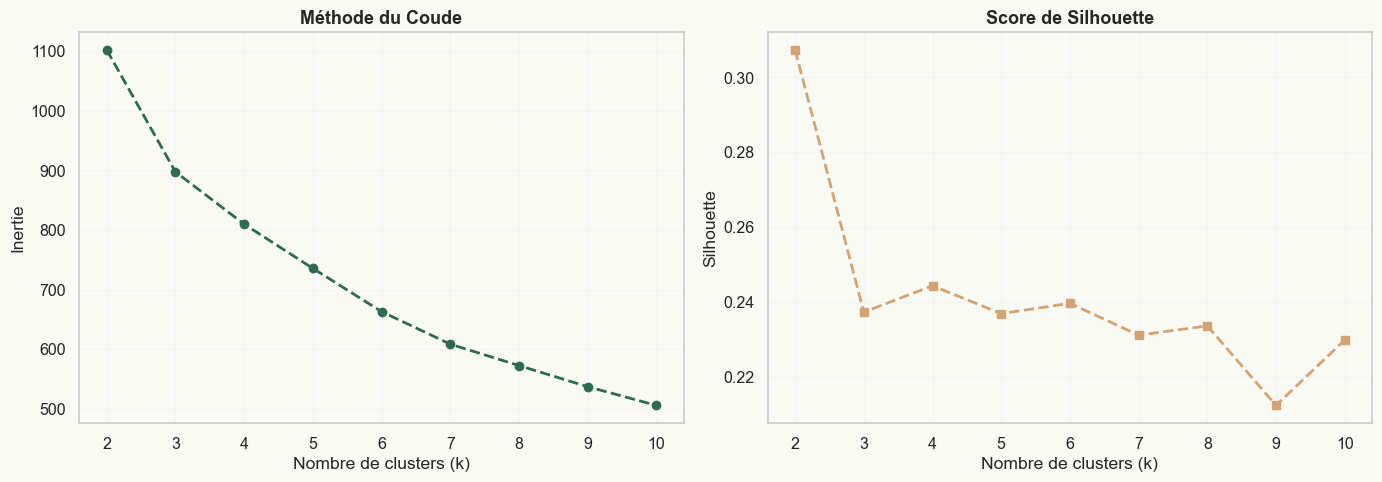

In [127]:
cols_clust = ["Conflit", "Water_Access", "population using the Internet", "Coastline",
              "Net_Migration", "Freedom_Score", "PM25", "Suicide_Rate",
              "GDP_per_capita", "HDI", "GII"]

df_clustering = df[['Country', 'Life_evaluation'] + cols_clust].copy()
imputer = KNNImputer(n_neighbors=5)
X_imputed = imputer.fit_transform(df_clustering[cols_clust])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# Méthode du Coude
inertias = []
sil_scores = []
K_range = range(2, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, km.labels_))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(K_range, inertias, marker='o', linestyle='--', color=PALETTE[0], linewidth=2)
ax1.set_title("Méthode du Coude", fontsize=13, fontweight='bold')
ax1.set_xlabel("Nombre de clusters (k)")
ax1.set_ylabel("Inertie")
ax1.set_xticks(list(K_range))
ax1.grid(True, alpha=0.3)

ax2.plot(K_range, sil_scores, marker='s', linestyle='--', color=ACCENT, linewidth=2)
ax2.set_title("Score de Silhouette", fontsize=13, fontweight='bold')
ax2.set_xlabel("Nombre de clusters (k)")
ax2.set_ylabel("Silhouette")
ax2.set_xticks(list(K_range))
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

La méthode du coude suggère $k = 2$ comme optimal, mais ce serait peu informatif. On utilise un **dendrogramme** pour affiner le choix.

### 5.2 Dendrogramme (Classification Hiérarchique)

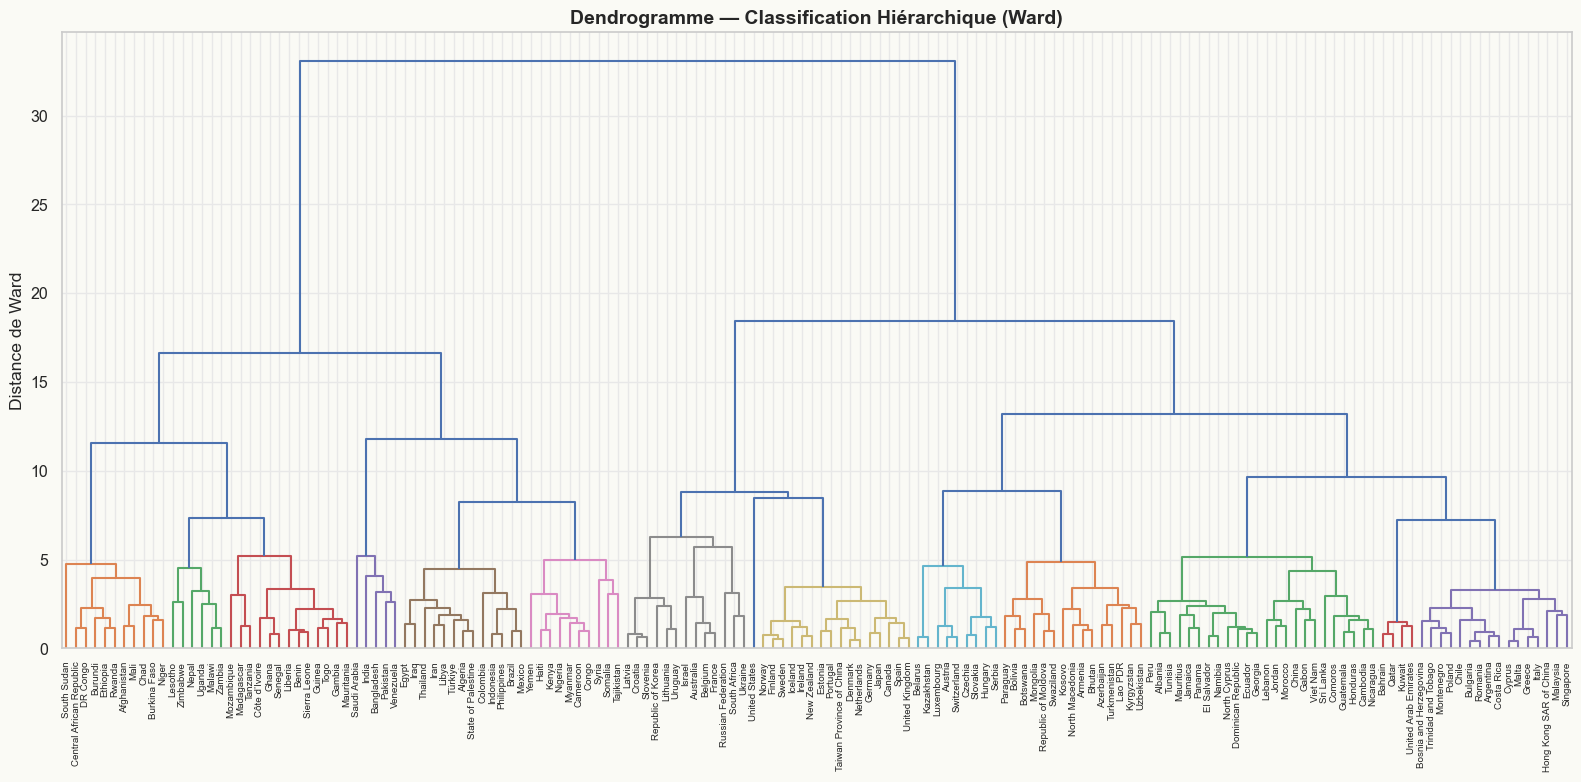

In [128]:
Z = linkage(X_scaled, method='ward')

fig, ax = plt.subplots(figsize=(16, 8))
dendro = dendrogram(Z, labels=df_clustering['Country'].values,
                    leaf_rotation=90., leaf_font_size=7., color_threshold=7, ax=ax)
ax.set_title("Dendrogramme — Classification Hiérarchique (Ward)", fontsize=14, fontweight='bold')
ax.set_ylabel("Distance de Ward")
plt.tight_layout()
plt.show()

Le dendrogramme montre **3 branches principales** bien séparées avant la fusion finale. On retient donc $k = 3$.

### 5.3 K-Means (k=3) et visualisation ACP

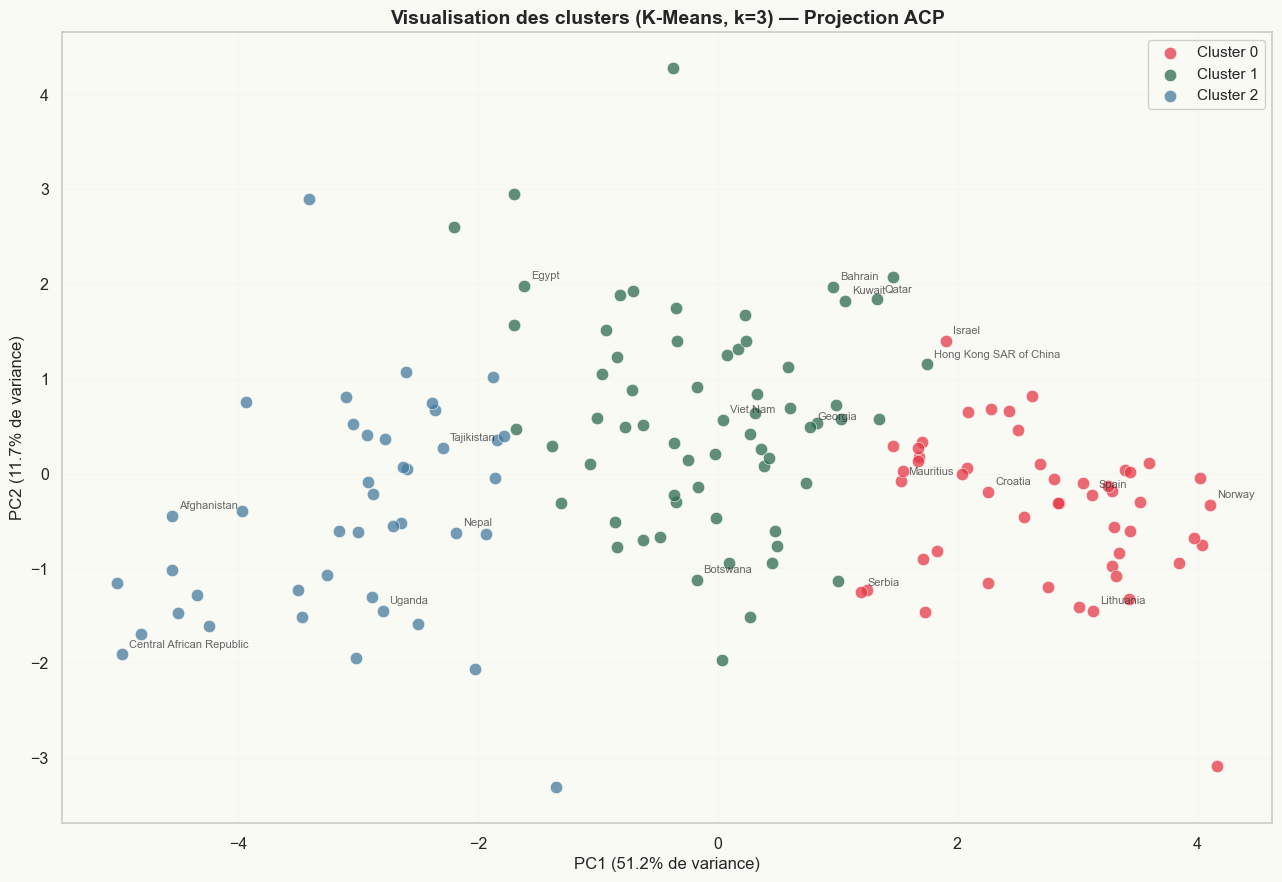

In [129]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_clustering['Cluster'] = kmeans.fit_predict(X_scaled).astype(int)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df_clustering['PC1'] = X_pca[:, 0]
df_clustering['PC2'] = X_pca[:, 1]

cluster_colors = {0: '#E63946', 1: '#2D6A4F', 2: '#457B9D'}

fig, ax = plt.subplots(figsize=(13, 9))
for cluster_id, color in cluster_colors.items():
    mask = df_clustering['Cluster'] == cluster_id
    ax.scatter(df_clustering.loc[mask, 'PC1'], df_clustering.loc[mask, 'PC2'],
               c=color, s=80, alpha=0.75, edgecolors='white', linewidth=0.5,
               label=f'Cluster {cluster_id}')

# Annotation de quelques pays
for i in range(0, len(df_clustering), 8):
    row = df_clustering.iloc[i]
    ax.annotate(row['Country'], (row['PC1'], row['PC2']),
                fontsize=8, alpha=0.7, ha='left',
                xytext=(5, 5), textcoords='offset points')

var1 = pca.explained_variance_ratio_[0] * 100
var2 = pca.explained_variance_ratio_[1] * 100
ax.set_xlabel(f"PC1 ({var1:.1f}% de variance)", fontsize=12)
ax.set_ylabel(f"PC2 ({var2:.1f}% de variance)", fontsize=12)
ax.set_title("Visualisation des clusters (K-Means, k=3) — Projection ACP", fontsize=14, fontweight='bold')
ax.legend(fontsize=11, framealpha=0.9)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

L'**axe 1 (PC1)** agit comme un indicateur de puissance socio-économique : il oppose les pays disposant d'un accès massif aux ressources (Internet, eau, PIB) aux pays marqués par des instabilités (conflits, inégalités).

L'**axe 2 (PC2)** apporte une nuance sur le contexte environnemental et social : il différencie les pays selon la pollution atmosphérique ou la santé mentale, facteurs qui ne dépendent pas uniquement du niveau de richesse.

### 5.4 Profils moyens par cluster

In [130]:
df_clustering['Coastline'] = df_clustering['Coastline'].astype(float)
profils = df_clustering.groupby('Cluster')[['Life_evaluation'] + cols_clust].mean().round(2)
profils

,Life_evaluation,Conflit,Water_Access,population using the Internet,Coastline,Net_Migration,Freedom_Score,PM25,Suicide_Rate,GDP_per_capita,HDI,GII
Cluster,,,,,,,,,,,,
0,6.48,0.10,99.24,83.22,0.84,106646.00,87.10,0.92,13.30,2.33,0.90,0.13
1,5.34,0.27,94.18,62.06,0.77,-49539.35,47.68,1.17,6.42,2.16,0.75,0.36
2,4.24,0.57,66.45,19.57,0.55,-55222.40,37.88,1.27,7.09,1.93,0.52,0.57


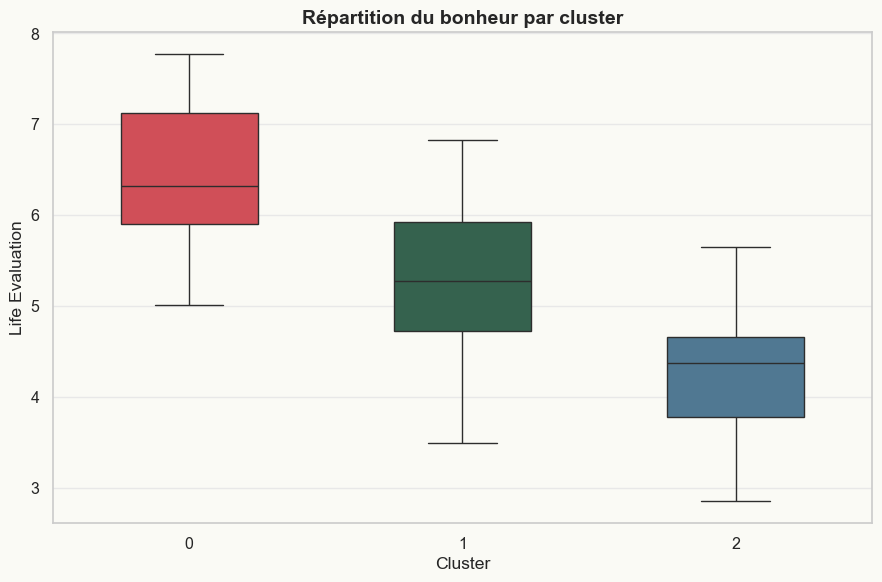

In [131]:
fig, ax = plt.subplots(figsize=(9, 6))
sns.boxplot(x='Cluster', y='Life_evaluation', data=df_clustering,
            palette=['#E63946', '#2D6A4F', '#457B9D'], width=0.5, ax=ax)
ax.set_title("Répartition du bonheur par cluster", fontsize=14, fontweight='bold')
ax.set_xlabel("Cluster")
ax.set_ylabel("Life Evaluation")
plt.tight_layout()
plt.show()

**Profils des clusters** :

- **Cluster 0** — *Structurellement contraint* : scores de bonheur les plus bas (médiane ~4.4). Ces pays partagent un accès limité à l'eau et à Internet, des scores de liberté faibles et des inégalités de genre marquées.
- **Cluster 1** — *Connecté et développé* : le groupe le plus homogène et le plus heureux (médiane ~6.5). Fort accès à Internet, IDH élevé, bonnes libertés individuelles.
- **Cluster 2** — *Intermédiaire / hybride* : le groupe le plus hétérogène (scores de ~3.5 à ~6.9). Des pays aux profils très différents s'y côtoient, illustrant les limites du K-Means face à des profils complexes.

### 5.5 Cas d'étude : Nicaragua vs Corée du Sud

In [132]:
comparaison = df_clustering[df_clustering['Country'].isin(['Costa Rica', 'Nicaragua', 'Republic of Korea'])]
cols_comp = ['Country', 'Cluster', 'Life_evaluation', 'GDP_per_capita', 'Freedom_Score',
             'GII', 'HDI', 'Suicide_Rate', 'PM25', 'Net_Migration', 'Coastline']
comparaison[cols_comp]

,Country,Cluster,Life_evaluation,GDP_per_capita,Freedom_Score,GII,HDI,Suicide_Rate,PM25,Net_Migration,Coastline
31,Costa Rica,0,7.167,2.245028,91.0,0.249,0.813,7.53,0.999428,1673.0,1.0
99,Nicaragua,1,6.105,2.030558,44.0,0.423,0.690,5.27,1.052082,-20742.0,1.0
113,Republic of Korea,0,5.895,2.348843,84.0,0.055,0.924,28.28,1.180367,118220.0,1.0


La **Corée du Sud** (Cluster 1) a un PIB par habitant massif et un score de liberté élevé. Pourtant, son score de bonheur est de 5.895, inférieur au **Nicaragua** (Cluster 2, score de 6.105) qui a un PIB et une liberté bien plus faibles.

Le taux de suicide illustre cette différence : 5.27 pour le Nicaragua (très bas) contre 28.28 pour la Corée du Sud.

Cette comparaison démontre que **le PIB est un prédicteur de la richesse, pas nécessairement de la plénitude**. Des facteurs culturels et sociaux — santé mentale, soutien communautaire — que les statistiques macro-économiques ne capturent pas totalement jouent un rôle déterminant.

### 5.6 Validation du clustering par le rang de bonheur

In [133]:
for c in range(kmeans.n_clusters):
    pays = df_clustering[df_clustering['Cluster'] == c]['Country'].values
    print(f"\nCluster {c} ({len(pays)} pays) : {', '.join(pays[:10])}{'...' if len(pays) > 10 else ''}")


Cluster 0 (50 pays) : Argentina, Australia, Austria, Belarus, Belgium, Bulgaria, Canada, Chile, Costa Rica, Croatia...

Cluster 1 (64 pays) : Albania, Algeria, Armenia, Azerbaijan, Bahrain, Bangladesh, Bhutan, Bolivia, Bosnia and Herzegovina, Botswana...

Cluster 2 (42 pays) : Afghanistan, Benin, Burkina Faso, Burundi, Cambodia, Cameroon, Central African Republic, Chad, Congo, DR Congo...


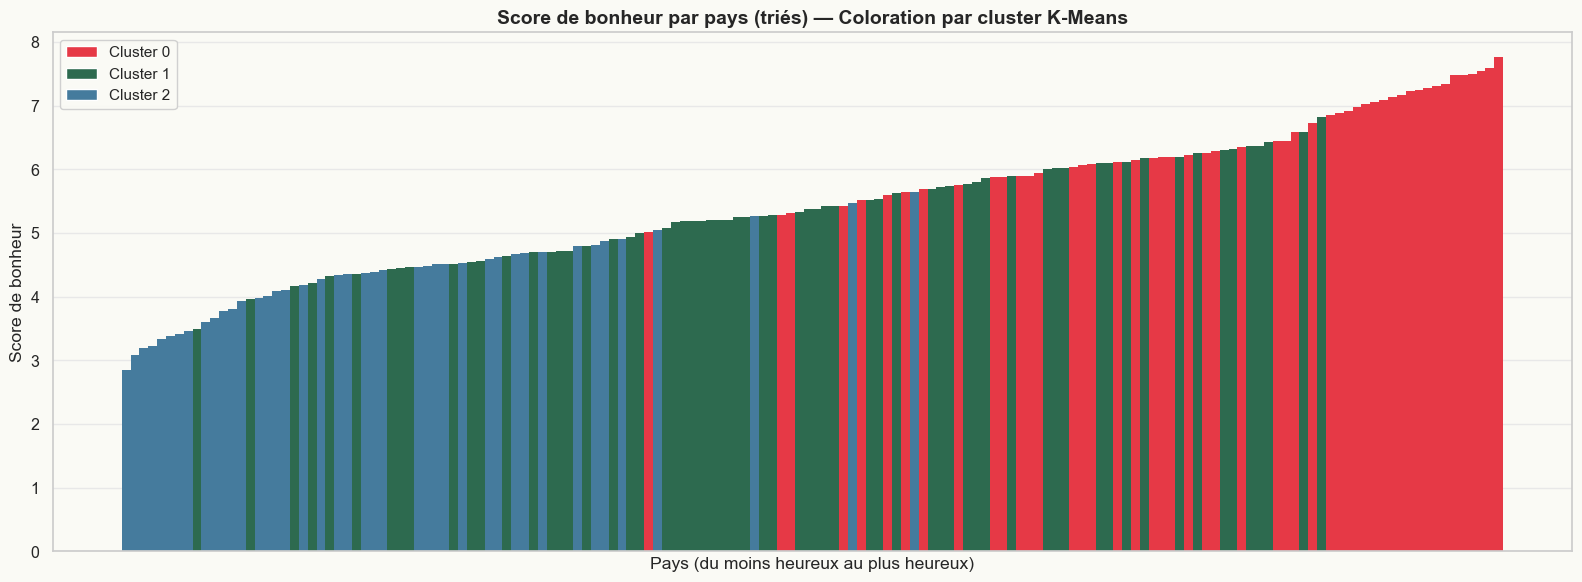

In [134]:
df_ranked = df_clustering.sort_values(by='Life_evaluation').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(16, 6))
for idx, row in df_ranked.iterrows():
    ax.bar(idx, row['Life_evaluation'], color=cluster_colors[row['Cluster']],
           edgecolor='none', width=1.0)


legend_elements = [Patch(facecolor=cluster_colors[i], label=f'Cluster {i}') for i in range(3)]
ax.legend(handles=legend_elements, fontsize=11, loc='upper left', framealpha=0.9)

ax.set_title("Score de bonheur par pays (triés) — Coloration par cluster K-Means",
             fontsize=14, fontweight='bold')
ax.set_xlabel("Pays (du moins heureux au plus heureux)")
ax.set_ylabel("Score de bonheur")
ax.set_xticks([])
plt.tight_layout()
plt.show()

Le K-Means, bien qu'il n'utilise pas `Life_evaluation` comme variable d'entrée, reproduit assez fidèlement le classement mondial de bonheur. C'est une **validation indirecte importante** : les variables socio-économiques choisies sont suffisamment représentatives pour que le clustering non supervisé retrouve spontanément l'ordre du bonheur.

Quelques barres isolées de couleur différente au milieu du graphique confirment les limites du K-Means sur les profils hybrides — notamment des pays comme la Chine, dont le profil économique fort mais le Freedom Score très bas crée une ambiguïté que l'algorithme ne résout pas parfaitement.

On retrouve le même problème que pour la classification : nos algorithmes identifient bien les extrêmes mais peinent avec les **profils intermédiaires**.

---
## 6. Conclusion

Au terme de cette étude, nos modèles convergent vers une même conclusion : **le développement économique** (PIB, accès à Internet) **est le meilleur prédicteur statistique du bonheur déclaré**, mais il n'en est pas la seule cause. La liberté individuelle, la qualité environnementale et des facteurs culturels non capturés par nos variables jouent un rôle significatif — notamment pour les pays à revenu intermédiaire, qui résistent systématiquement à la modélisation.

**Question ouverte** : nos modèles montrent une corrélation entre richesse et bonheur, mais est-ce que la richesse *cause* le bonheur, ou est-ce l'inverse (les gens heureux sont plus productifs) ? Ou bien les deux sont-ils causés par un facteur tiers (stabilité politique, capital social…) que nous n'avons pas réussi à intégrer ? Cette question fondamentale de **causalité** reste ouverte et dépasse le cadre de la modélisation statistique.